**historical stock analysis - assignment 2 eda**

exploratory data analysis on the stock data csv. answers follow the worksheet order (part 0 through part 5), each figure captioned with interpretation underneath.

**what these columns mean**

- Date: the calendar day of a trading session, no time of day attached

- Ticker: the symbol identifying which company's stock the row belongs to, one ticker per publicly listed company. the suffix at the end tells you which stock exchange it trades on, no suffix means it trades in the United States, other suffixes mean other countries and other currencies

- Open: the price the stock traded at the moment the market opened that day

- High: the highest price the stock touched at any point during that trading day

- Low: the lowest price the stock touched at any point during that trading day

- Close: the price the stock traded at the moment the market closed that day. companies occasionally do a stock split, dividing each existing share into several smaller ones so the per share price drops without changing what a shareholder actually owns, and Close already accounts for that, so past splits do not show up as sudden price jumps

- Adj Close: the same closing price, additionally adjusted for dividends, which are periodic cash payments a company makes to its shareholders. a dividend payment mechanically lowers the stock price by roughly the payment amount, so Adj Close corrects for that too. this is the number to use when measuring how much money an investment actually made over time

- Volume: how many shares of that stock changed hands that day, a measure of trading activity rather than price

**part 0: setup and data overview**

**q0.1 load the dataset and report its shape**

In [1]:
import pandas as pd

df = pd.read_csv("data/stock_data.csv", parse_dates=["Date"])
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2006-01-02,000660.KS,36100.0,37650.0,35850.0,37600.0,27358.396484,13334311.0
1,2006-01-03,000660.KS,38100.0,38400.0,36850.0,38200.0,27794.970703,13815168.0
2,2006-01-04,000660.KS,38250.0,39050.0,35300.0,35400.0,25757.650391,23064896.0
3,2006-01-05,000660.KS,35900.0,36000.0,33600.0,34750.0,25284.687500,21043236.0
4,2006-01-06,000660.KS,34950.0,35850.0,34850.0,35100.0,25539.355469,12557226.0


In [2]:
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
print()
print(df.dtypes)

rows: 230111, columns: 8

Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object


- the dataset has 230,111 rows and 8 columns: Date (datetime), Ticker (string), Open, High, Low, Close, Adj Close (all float64), and Volume (float64)

- this matches what we expected going in, one row per ticker per trading day across 49 tickers, with no surprises in row count or column types

- the one thing worth flagging is Volume loading as float64 rather than an integer type, since share counts are whole numbers, likely just how the source csv was written

**q0.2 summary statistics for numeric columns**

In [3]:
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
desc = df[numeric_cols].describe()
desc

,Open,High,Low,Close,Adj Close,Volume
count,230111.000000,230111.000000,230111.000000,230111.000000,230111.000000,2.301110e+05
mean,2596.657730,2633.517954,2561.272554,2597.577298,2372.899526,5.733504e+07
std,19068.219340,19451.492406,18768.545067,19141.577619,18653.369016,1.487669e+08
min,0.150000,0.159500,0.143750,0.147500,0.135233,0.000000e+00
25%,25.080000,25.375500,24.790001,25.083332,19.609505,4.812100e+06
50%,63.740002,64.294998,63.180000,63.770000,48.448479,1.329630e+07
75%,139.750000,140.974998,138.440002,139.750000,122.790493,3.727400e+07
max,905000.000000,955000.000000,888000.000000,949000.000000,949000.000000,1.881051e+10


In [4]:
stats = pd.DataFrame({
    "range": desc.loc["max"] - desc.loc["min"],
    "mean_minus_median": desc.loc["mean"] - desc.loc["50%"]
})
stats

,range,mean_minus_median
Open,9.049998e+05,2.532918e+03
High,9.549998e+05,2.569223e+03
Low,8.879999e+05,2.498093e+03
Close,9.489999e+05,2.533807e+03
Adj Close,9.489999e+05,2.324451e+03
Volume,1.881051e+10,4.403874e+07


- Volume has the widest range by far, from 0 to about 18.8 billion, but that number is not comparable to the price columns since it is a share count, not a price. reading it as "Volume varies most" would be misleading

- among the price columns, High has the widest range, about 955,000, versus around 888,000 to 949,000 for the others. that spread is inflated by mixing currencies. some tickers trade in Korean won at levels in the hundreds of thousands, so a KRW stock alone can stretch the range without the dollar-denominated stocks moving at all

- the largest mean minus median gap is also Volume, about 44 million, meaning a small number of very high volume days or tickers pull the average well above the typical day

- every price column shows the same pattern at a smaller scale: mean around 2,400 to 2,600 against a median around 48 to 64, roughly a 40x gap. this is the currency mixing problem again, not genuine skew in any single stock, the high won-denominated prices drag the mean far above where most tickers actually sit

**q0.3 quantify missing data by column**

In [5]:
missing = df.isna().sum()
missing

Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

- every column shows a count of zero in the table above, no missing values anywhere

- nothing needs to be dropped or imputed for missingness. this matches what we already knew about the dataset going in

- this does not mean the data is free of quirks. the currency mixing seen in q0.2 and the staggered start dates for a handful of tickers are real issues, they just do not show up as missing values, they show up as values that need normalizing before comparison

**part 1: univariate exploration**

**q1.1 distribution of the key numeric variable**

the numeric variable most central to this project is daily return, how much a stock's price moved from one day to the next, as a percentage. raw price cannot be used directly for this because the 49 tickers trade in different currencies, so a single price histogram would just describe currency scale, not stock behavior. daily return is currency free and is the variable every candidate hypothesis so far, ai rally narrowness, diversification, volatility regimes, is actually built on

In [6]:
df = df.sort_values(["Ticker", "Date"])
df["Daily Return"] = df.groupby("Ticker")["Adj Close"].pct_change()

returns = df["Daily Return"].dropna()
returns.describe()

count    230062.000000
mean          0.000829
std           0.021381
min          -0.351166
25%          -0.008332
50%           0.000378
75%           0.009733
max           0.522901
Name: Daily Return, dtype: float64

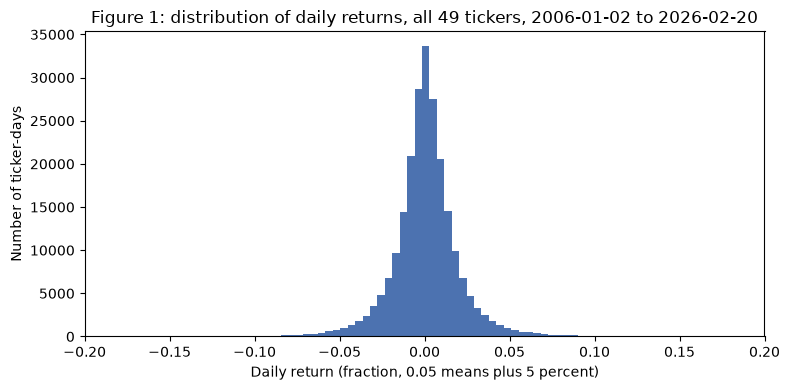

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(returns, bins=200, color="#4C72B0")
ax.set_xlim(-0.2, 0.2)
ax.set_title("Figure 1: distribution of daily returns, all 49 tickers, 2006-01-02 to 2026-02-20")
ax.set_xlabel("Daily return (fraction, 0.05 means plus 5 percent)")
ax.set_ylabel("Number of ticker-days")
plt.tight_layout()
plt.show()

- the distribution in Figure 1 is roughly symmetric and centered near zero, mean 0.08 percent and median 0.04 percent a day, which makes sense, most days a stock does not move much in either direction

- the shape is not a clean bell curve. it has a sharp narrow peak right at zero and long thin tails stretching out to minus 35 percent and plus 52 percent in a single day. those extreme days are individually rare but far more common than a normal distribution would predict

- this shape is a known feature of financial data, not a data quality problem, calm days cluster tightly while a small number of days carry outsized moves, most likely earnings surprises or market wide shocks like 2008 or 2020. this is also a first hint in favor of the volatility regimes candidate hypothesis, a small share of days may be doing most of the work

**q1.2 category counts for a key categorical variable**

the categorical variable here is market, which country's exchange a ticker trades on, derived from the ticker suffix. this is a different plotting library from q1.1, pandas own plotting interface instead of calling matplotlib directly

In [8]:
def get_market(ticker):
    if ticker.endswith(".KS"):
        return "Korea"
    elif ticker.endswith(".HK"):
        return "Hong Kong"
    elif ticker.endswith(".SW"):
        return "Switzerland"
    elif ticker.endswith(".PA"):
        return "Paris"
    elif ticker.endswith(".SR"):
        return "Saudi Arabia"
    else:
        return "United States"

df["Market"] = df["Ticker"].apply(get_market)
market_counts = df["Market"].value_counts()
market_counts

Market
United States    184793
Hong Kong         18532
Switzerland       10140
Korea              9944
Paris              5152
Saudi Arabia       1550
Name: count, dtype: int64

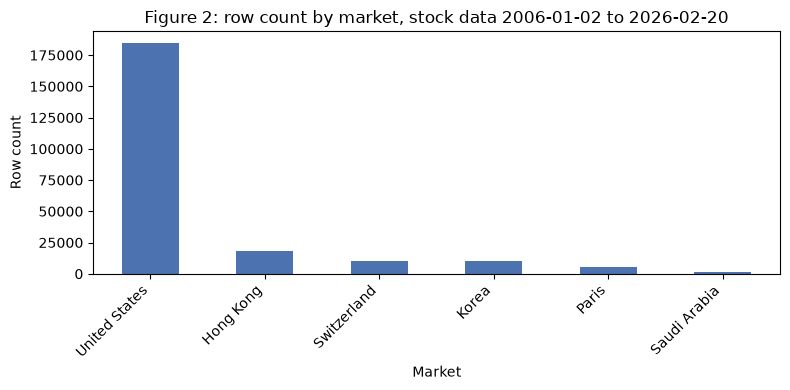

In [9]:
ax = market_counts.plot(kind="bar", figsize=(8, 4), color="#4C72B0")
ax.set_title("Figure 2: row count by market, stock data 2006-01-02 to 2026-02-20")
ax.set_xlabel("Market")
ax.set_ylabel("Row count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- the categories are heavily skewed. United States rows are 184,793 out of 230,111 total, about 80 percent, while Saudi Arabia has only 1,550 and Paris only 5,152

- most of that imbalance is simply ticker count, not some markets trading more often. 39 of the 49 tickers are United States listed, versus 4 in Hong Kong, 2 each in Switzerland and Korea, and just 1 each in Paris and Saudi Arabia

- this matters a lot for later analysis. Paris and Saudi Arabia are each represented by a single company, so anything we say about "the Paris market" or "the Saudi market" in this dataset is really only a statement about one stock, not a region. any regional comparison needs to be read with that in mind, and a naive global average would be almost entirely a United States average

**q1.3 box plot for outliers in the key numeric variable (optional)**

checking daily return, the same variable from q1.1, for outliers. using seaborn here, a third plotting library after matplotlib in q1.1 and pandas plotting in q1.2

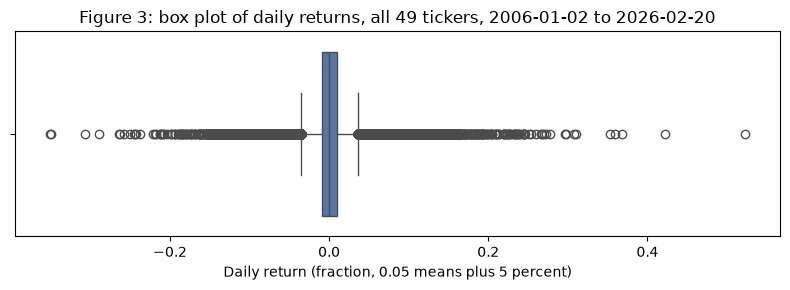

In [10]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=returns, ax=ax, color="#4C72B0")
ax.set_title("Figure 3: box plot of daily returns, all 49 tickers, 2006-01-02 to 2026-02-20")
ax.set_xlabel("Daily return (fraction, 0.05 means plus 5 percent)")
plt.tight_layout()
plt.show()

In [11]:
q1, q3 = returns.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_share = ((returns < lower_fence) | (returns > upper_fence)).mean()
print(f"outlier fence: {lower_fence:.4f} to {upper_fence:.4f}")
print(f"share of days outside the fence: {outlier_share:.2%}")

df.loc[returns.index].nsmallest(5, "Daily Return")[["Date", "Ticker", "Daily Return"]]

outlier fence: -0.0354 to 0.0368
share of days outside the fence: 7.24%


,Date,Ticker,Daily Return
173753,2022-04-20,NFLX,-0.351166
171115,2011-10-25,NFLX,-0.348956
180415,2008-07-03,NVDA,-0.307266
65670,2009-01-20,BAC,-0.289694
153441,2022-02-03,META,-0.263901


In [12]:
df.loc[returns.index].nlargest(5, "Daily Return")[["Date", "Ticker", "Daily Return"]]

,Date,Ticker,Daily Return
40988,2016-04-22,AMD,0.522901
171427,2013-01-24,NFLX,0.422235
63917,2022-03-16,BABA,0.367639
189803,2025-09-10,ORCL,0.359488
65726,2009-04-09,BAC,0.352691


- Figure 3 shows a very tight box, most days sit within about minus 3.5 percent to plus 3.7 percent, but with dense clusters of points scattered far past both whiskers. about 7.2 percent of all ticker-days fall outside that fence

- the five most negative days line up with real, well known events, not data errors. netflix dropped 35 percent on 2022-04-20 and 35 percent again on 2011-10-25, both known subscriber loss shocks, nvidia fell 31 percent on 2008-07-03 during the financial crisis, bank of america fell 29 percent on 2009-01-20 also during the financial crisis, and meta fell 26 percent on 2022-02-03, its largest single day drop on record

- the five most positive days tell the same story from the other side. amd jumped 52 percent on 2016-04-22 and netflix jumped 42 percent on 2013-01-24, both post earnings rallies, and bank of america jumped 35 percent on 2009-04-09 during the crisis recovery. these are genuinely extreme trading days for specific companies, not glitches in the data, so they should stay in the dataset rather than being filtered out as errors

**part 2: relationships between variables**

**q2.1 scatter plot of two related numeric variables**

checking whether bigger trading volume days tend to come with bigger price moves. plotting volume against the size of the daily return, direction ignored, since the question is about magnitude of the move, not which way it went. volume is log scaled because it spans several orders of magnitude, and 3,000 randomly sampled points are plotted instead of all 230,062, since plotting everything would just render as a solid block

In [3]:
plot_df = df.dropna(subset=["Daily Return"]).copy()
plot_df["Abs Daily Return"] = plot_df["Daily Return"].abs()

sample = plot_df.sample(3000, random_state=42)
correlation = plot_df["Volume"].corr(plot_df["Abs Daily Return"])
print(f"pearson correlation, volume vs absolute daily return, full data: {correlation:.3f}")

pearson correlation, volume vs absolute daily return, full data: 0.207


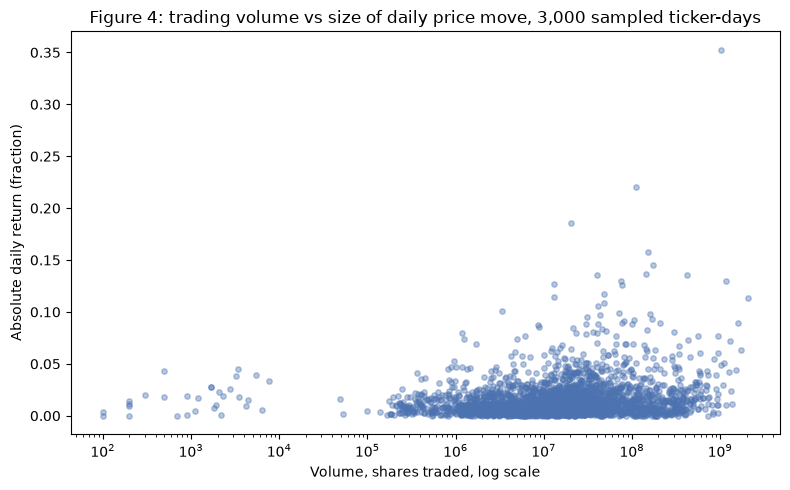

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["Volume"], sample["Abs Daily Return"], alpha=0.4, s=15, color="#4C72B0")
ax.set_xscale("log")
ax.set_title("Figure 4: trading volume vs size of daily price move, 3,000 sampled ticker-days")
ax.set_xlabel("Volume, shares traded, log scale")
ax.set_ylabel("Absolute daily return (fraction)")
plt.tight_layout()
plt.show()

- the relationship in Figure 4 is positive but weak, pearson correlation 0.21. higher volume days lean toward slightly bigger price moves, but the cloud of points is wide, not a tight line

- it is not linear even on the log volume axis, it looks more like a widening funnel, low volume days are almost always small moves, but high volume days can be either small or huge, volume raises the ceiling on how big a move can get without guaranteeing a big move happens

- this is a weak signal at best. volume alone would be a poor predictor of an individual day's move size, which is worth remembering before leaning on volume as an early warning sign for anything downstream

**q2.2 correlation heatmap**

a correlation heatmap of Open, High, Low, Close, Adj Close would just show near perfect correlation, since those four are all derived from the same daily trading range for the same ticker. a more useful version for this project is a correlation heatmap of daily returns across different tickers, since that speaks directly to two of our candidate hypotheses, whether chip makers move together and apart from everything else, and whether stocks in different regions are actually diversified from each other. picking a defensible handful, chip names nvidia, broadcom, tsmc, asml, and amd, broader tech names apple and microsoft, and one non united states name outside tech, lvmh in paris, to test cross region correlation

In [15]:
tickers_of_interest = ["NVDA", "AVGO", "TSM", "ASML", "AMD", "AAPL", "MSFT", "MC.PA"]
returns_wide = df[df["Ticker"].isin(tickers_of_interest)].pivot(
    index="Date", columns="Ticker", values="Daily Return"
)
corr_matrix = returns_wide.corr()
corr_matrix

Ticker,AAPL,AMD,ASML,AVGO,MC.PA,MSFT,NVDA,TSM
Ticker,,,,,,,,
AAPL,1.000000,0.381056,0.478143,0.479662,0.285606,0.536714,0.472396,0.462894
AMD,0.381056,1.000000,0.462079,0.414750,0.254129,0.403154,0.529597,0.453562
ASML,0.478143,0.462079,1.000000,0.576774,0.400305,0.535846,0.588645,0.627248
AVGO,0.479662,0.414750,0.576774,1.000000,0.268954,0.484901,0.547381,0.560607
MC.PA,0.285606,0.254129,0.400305,0.268954,1.000000,0.329611,0.271580,0.341721
MSFT,0.536714,0.403154,0.535846,0.484901,0.329611,1.000000,0.526393,0.484596
NVDA,0.472396,0.529597,0.588645,0.547381,0.271580,0.526393,1.000000,0.582945
TSM,0.462894,0.453562,0.627248,0.560607,0.341721,0.484596,0.582945,1.000000


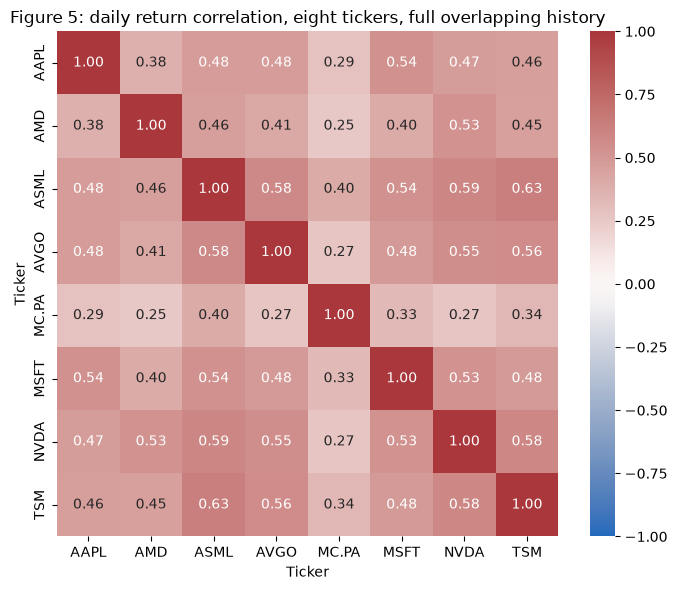

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Figure 5: daily return correlation, eight tickers, full overlapping history")
plt.tight_layout()
plt.show()

- the strongest pair is asml and tsm at 0.63, closely followed by asml-nvidia at 0.59 and tsm-nvidia at 0.58. the five chip names cluster together at 0.53 to 0.63 with each other, noticeably tighter than their correlation with apple or microsoft, which sit more in the 0.38 to 0.54 range against the chip names

- the weakest pair by a wide margin is lvmh against everything else, 0.25 to 0.40, well below any of the tech to tech pairs. lvmh is both non tech and the only non united states name here, so this cannot separate whether the gap is about sector or region

- neither result was surprising given what we set out to test, but seeing actual numbers matters. the chip names genuinely do move more tightly with each other than with broader tech, which is a real point in favor of the ai rally narrowness hypothesis, and lvmh's weak correlation is a real point in favor of the diversification hypothesis, though this heatmap uses the full history average and does not yet check whether that gap holds up specifically during crisis periods

**q2.3 recreate a plot interactively**

recreating the figure 4 scatter plot, volume against size of daily move, with plotly. the hover tooltip adds ticker and date, two fields the static matplotlib version could not show per point

In [17]:
import plotly.express as px

fig = px.scatter(
    sample,
    x="Volume",
    y="Abs Daily Return",
    hover_data=["Ticker", "Date"],
    log_x=True,
    opacity=0.5,
    title="Figure 6: trading volume vs size of daily price move, interactive, 3,000 sampled ticker-days",
    labels={"Volume": "Volume, shares traded, log scale", "Abs Daily Return": "Absolute daily return (fraction)"},
)
fig.show()

In [18]:
sample.nlargest(10, "Volume")[["Date", "Ticker", "Volume", "Abs Daily Return"]]

,Date,Ticker,Volume,Abs Daily Return
181059,2011-01-24,NVDA,2.056900e+09,0.112962
181091,2011-03-10,NVDA,1.722736e+09,0.063741
180468,2008-09-18,NVDA,1.611060e+09,0.089000
182555,2017-01-03,NVDA,1.501996e+09,0.044313
182687,2017-07-13,NVDA,1.369132e+09,0.011568
180003,2006-11-10,NVDA,1.317192e+09,0.024087
180627,2009-05-07,NVDA,1.289196e+09,0.071800
181116,2011-04-14,NVDA,1.254704e+09,0.042230
24209,2008-10-30,1398.HK,1.179276e+09,0.130031
30578,2008-03-14,AAPL,1.156641e+09,0.010395


- the ticker field the hover tooltip adds shows something the static Figure 4 could not, the ten highest volume points in this sample are almost all one company, nvidia appears 8 of the top 10, with 1398.HK and apple filling the other two

- that is a real pattern worth flagging, not just a coincidence of sampling. nvidia has gone through multiple stock splits over this period, which multiplies its share count without changing the dollar value traded, so some of nvidia's apparent volume dominance here may be a share count artifact of splits rather than genuinely outsized trading interest compared to other large names

- this is exactly the kind of detail a hover tooltip is good for and a static plot is not, it let us catch a possible confound, split driven share count inflation, that the correlation number and the plain scatter shape alone would not have surfaced

**part 3: group and categorical comparisons**

**q3.1 compare a numeric outcome across groups**

grouping by market, the same categorical variable from q1.2, and comparing mean daily return and its standard deviation across groups

In [19]:
market_stats = df.dropna(subset=["Daily Return"]).groupby("Market")["Daily Return"].agg(["mean", "std"])
market_stats = market_stats.sort_values("mean", ascending=False)
market_stats

,mean,std
Market,,
Korea,0.000940,0.023671
United States,0.000864,0.021917
Hong Kong,0.000792,0.019885
Paris,0.000628,0.018208
Switzerland,0.000361,0.012745
Saudi Arabia,0.000145,0.010521


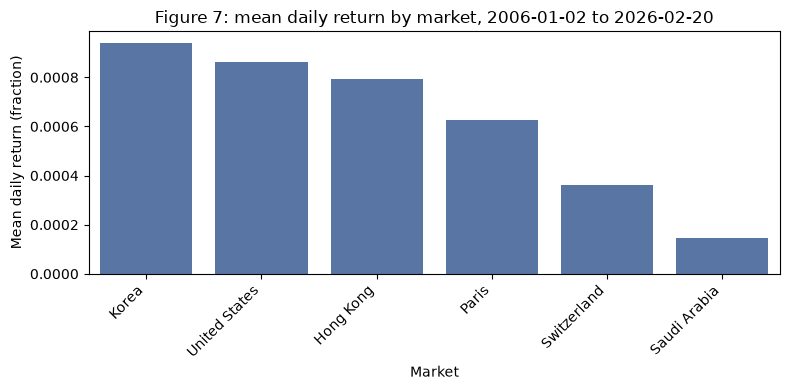

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=market_stats.index, y=market_stats["mean"], ax=ax, color="#4C72B0")
ax.set_title("Figure 7: mean daily return by market, 2006-01-02 to 2026-02-20")
ax.set_xlabel("Market")
ax.set_ylabel("Mean daily return (fraction)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- Figure 7 shows a fairly consistent order, korea has the highest mean daily return at 0.094 percent, followed by united states at 0.086 percent, hong kong, paris, switzerland, and saudi arabia lowest at 0.015 percent

- the standard deviation column lines up with the same order, korea is also the most volatile at 2.37 percent daily and saudi arabia the calmest at 1.05 percent, so in this dataset higher average return and higher volatility travel together across markets

- this needs a strong caveat carried over from q1.2, saudi arabia, paris, and switzerland are represented by one or two tickers each, so these are not really market wide statistics, they are statistics about a handful of individual companies wearing a market label. the pattern is worth noting but should not be described as "korea outperforms" or "saudi arabia is safest" without that caveat attached

**q3.2 key variable over time**

plotting price over time for the chip names against apple and microsoft, indexed to 100 at a common start date so the different starting prices and currencies do not distort the comparison. broadcom is the latest starter of this group, so 2009-08-06 is the first date every ticker in this chart has data, that date is the rebase point

In [21]:
chart_tickers = ["NVDA", "AVGO", "TSM", "ASML", "AAPL", "MSFT"]
prices_wide = df[df["Ticker"].isin(chart_tickers)].pivot(index="Date", columns="Ticker", values="Adj Close")

rebase_date = prices_wide.dropna().index.min()
indexed = prices_wide.loc[rebase_date:] / prices_wide.loc[rebase_date] * 100

print(f"rebase date: {rebase_date.date()}")
indexed.tail()

rebase date: 2009-08-06


Ticker,AAPL,ASML,AVGO,MSFT,NVDA,TSM
Date,,,,,,
2026-02-13,5208.056771,5979.010521,28529.327165,2312.051344,60790.435402,5754.607682
2026-02-17,5372.984802,6034.991804,29175.945836,2286.356671,61508.708827,5720.679855
2026-02-18,5382.554718,6243.018498,29261.050492,2302.142155,62509.632622,5690.207223
2026-02-19,5305.791579,6201.404961,29303.162369,2300.814011,62483.029339,5660.834233
2026-02-20,5387.237459,6246.716545,29185.595582,2293.711776,63121.497989,5820.265490


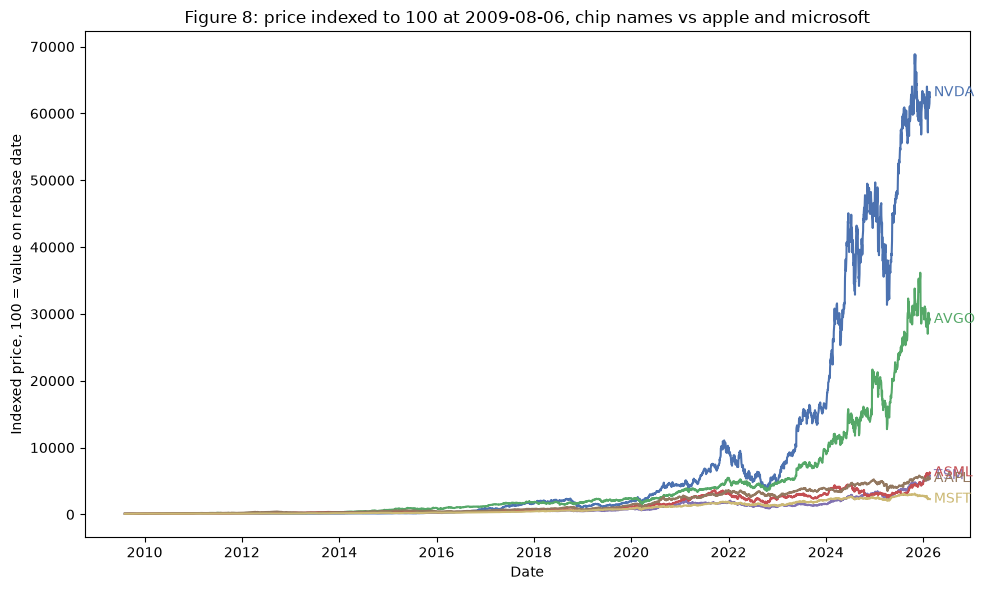

In [22]:
colors = {
    "NVDA": "#4C72B0", "AVGO": "#55A868", "TSM": "#8172B2",
    "ASML": "#C44E52", "AAPL": "#937860", "MSFT": "#CCB974",
}

fig, ax = plt.subplots(figsize=(10, 6))
for ticker in chart_tickers:
    ax.plot(indexed.index, indexed[ticker], color=colors[ticker], linewidth=1.5)
    ax.text(indexed.index[-1], indexed[ticker].iloc[-1], f" {ticker}", color=colors[ticker], va="center")

ax.set_title(f"Figure 8: price indexed to 100 at {rebase_date.date()}, chip names vs apple and microsoft")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price, 100 = value on rebase date")
plt.tight_layout()
plt.show()

- Figure 8 ends on a huge spread. from the same starting value of 100 on 2009-08-06, nvidia reaches about 63,100 by 2026-02-20, roughly 631 times its starting value, broadcom reaches about 29,200, roughly 292 times. asml and tsm sit far behind that pair at roughly 62 and 58 times, apple at roughly 54 times, and microsoft trails the whole group at roughly 23 times

- this is a genuine and large gap, not a rounding difference, and it lines up with the ai rally narrowness hypothesis, chip names as a group did substantially better than apple and especially microsoft over this window

- but it complicates the simple version of that hypothesis. the crack test we planned was whether the story survives with nvidia removed, and looking at Figure 8, broadcom alone still clearly justifies a chip outperformance story even without nvidia, but asml and tsm do not, they end up closer to apple's growth than to nvidia or broadcom's. the honest version of this hypothesis may need to single out nvidia and broadcom specifically rather than treating all five chip names as one interchangeable group

**part 4: data quality notes**

**q4.1 data quality issues**

- mixed currencies across tickers. this first showed up in the q0.2 summary statistics table, where the price columns had a roughly 40 times gap between mean and median that had nothing to do with any single stock's behavior, it was won denominated prices sitting at a completely different scale than dollar denominated ones. every chart that mixes tickers in this notebook had to work around this, by using returns instead of raw price, or by indexing to 100

- heavy imbalance in the market category, revealed in Figure 2. united states rows are about 80 percent of the dataset, and two of the six market labels, paris and saudi arabia, are each backed by a single company. any statistic broken out by market, including Figure 7 in q3.1, is really describing individual companies in the smaller markets, not the market as a whole

- staggered ticker start dates. this surfaced while building Figure 8, broadcom does not begin until 2009-08-06, years after the other five tickers in that chart. an index to 100 chart rebased at any earlier date would have silently dropped broadcom or produced a broken line, so the rebase date had to be chosen deliberately as the latest of the six start dates

**part 5: synthesis and reflection**

**q5.1 three key findings**

- Figure 8 shows the ai rally narrowness idea is real but not evenly true across the whole chip group. nvidia and broadcom pulled dramatically ahead, 631 times and 292 times their 2009 value, while asml and tsm only reached roughly 58 to 62 times, barely ahead of apple's 54 times. the central hypothesis likely needs to be about specific standout names, not the chip sector as a block

- Figure 5 shows the five chip names correlate more tightly with each other, 0.53 to 0.63, than with apple or microsoft, 0.38 to 0.54, and far more than with lvmh, 0.25 to 0.40. this is independent evidence for the same narrowness story from a different angle, the chip names do not just grow together, their day to day moves are more tied to each other than to the rest of large cap tech

- Figure 1 and Figure 3 together show daily returns are sharply peaked near zero with fat tails, about 7.2 percent of ticker days sit outside the standard box plot fence, and the most extreme days line up with specific known events like the 2008 crisis and company earnings shocks rather than being spread evenly through time. this supports the volatility regimes candidate as a plausible sub claim, a small share of days may carry most of the total movement

**q5.2 most insightful library or plot type**

the matplotlib indexed line chart in Figure 8 gave the most direct insight for this specific project. it is the one plot that actually put a number on the leading candidate hypothesis instead of just gesturing at it, and it did so in a way that changed our thinking, the story survives without nvidia because of broadcom, but it does not survive intact across all five chip names, which is a more precise and more defensible version of the hypothesis than the one we started with

**q5.3 one open question**

Figure 5's correlation heatmap uses the full 2006 to 2026 average, but the diversification candidate hypothesis specifically claims correlation rises during crises. we still do not know whether the chip cluster's correlation with each other, or lvmh's low correlation with everyone, actually holds during 2008, 2020, and 2022 specifically, or whether it only looks stable because it is averaged over many calm years alongside the volatile ones